In [1]:
from pathlib import Path
import pickle
import re

import matplotlib.pyplot as plt
import numpy as np


# Parameters that identify the runs, as in the filenames written by hiv_simulations.py:
# hiv_model{model}_ninit{n_init}_n{n}_B{resamplings}[_shuffled]_seed{seed}_martingales.pkl
model = "lassocv"
n_init = 500
n = 1555                # number of samples used (the whole dataset when --n is not given)
resamplings = 20        # --resamplings, the "B" in the filename
shuffled = True        # --shuffle
alpha = 0.05

# Folders to read; the strategies of all folders are merged seed by seed (the first folder wins on duplicates).
# A pickle holds a single KDE, so to plot both variants run hiv_simulations.py again with the other one
# (e.g. --strategies kde, with or without --kde_two_dimensional) into a different --output_dir and add it here.
results_dirs = [Path("../../results/csv/hiv")]

In [2]:
# The "kde" strategy is renamed after the variant it was run with (--kde_two_dimensional)
KDE_NAMES = {True: "kde_2d", False: "kde_1d"}


def load_runs(results_dir):
    """Load every seed saved with the parameters above. Returns {seed: result_dict}."""
    pattern = re.compile(
        rf"hiv_model{re.escape(model)}_ninit{n_init}_n{n}_B{resamplings}{'_shuffled' if shuffled else ''}"
        rf"_seed(\d+)_martingales\.pkl"
    )
    runs = {}
    for file in results_dir.iterdir():
        match = pattern.fullmatch(file.name)
        if match:
            with open(file, "rb") as f:
                run = pickle.load(f)
            if "kde" in run["martingales"]:
                kde_name = KDE_NAMES[bool(run["config"].get("kde_two_dimensional", False))]
                run["martingales"][kde_name] = run["martingales"].pop("kde")
            runs[int(match.group(1))] = run
    if not runs:
        raise FileNotFoundError(f"No files for model={model}, n_init={n_init}, n={n}, B={resamplings}, "
                                f"shuffled={shuffled} in {results_dir.resolve()}")
    runs = dict(sorted(runs.items()))
    print(f"{results_dir}: loaded {len(runs)} seed(s) {list(runs)}, strategies {list(runs[next(iter(runs))]['martingales'])}")
    return runs


runs_per_dir = [load_runs(d) for d in results_dirs]
seeds = sorted(set.intersection(*(set(runs) for runs in runs_per_dir)))
if any(set(runs) != set(seeds) for runs in runs_per_dir):
    print(f"warning: using only the seeds present in every folder: {seeds}")
first = runs_per_dir[0][seeds[0]]

features = first["config"]["features"]
batch_list = sorted(first["config"]["batches"])
for runs in runs_per_dir:
    for s in seeds:
        if runs[s]["config"]["features"] != features or sorted(runs[s]["config"]["batches"]) != batch_list:
            raise ValueError(f"seed {s} was run with different features or batch sizes than the first folder")

# Merge the strategies of all folders, seed by seed
martingales = {s: {} for s in seeds}
for runs in runs_per_dir:
    for s in seeds:
        for name, m in runs[s]["martingales"].items():
            martingales[s].setdefault(name, m)
strategies = list(martingales[seeds[0]])
if any(set(martingales[s]) != set(strategies) for s in seeds):
    raise ValueError("not every seed has the same strategies")

# For every strategy and feature: the e-process averaged over batch sizes, one row per seed, shape (n_seeds, n - n_init)
mean_processes = {
    name: {
        j: np.stack([np.mean([martingales[s][name][b][j] for b in batch_list], axis=0)[n_init:]
                     for s in seeds])
        for j in features
    }
    for name in strategies
}

../../results/csv/hiv: loaded 49 seed(s) [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 47, 48, 49, 50], strategies ['exponential', 'generalized_sign', 'tanh', 'sign', 'sign_preq', 'kde_2d']


In [8]:
#check if any of the strategies rejects feature 12S
for s in seeds:
    for name in strategies:
        for b in batch_list:
            if np.any(martingales[s][name][b][10] > 1/alpha):
                    print(f"seed {s} batch size {b} strategy {name} rejects feature 12S")

seed 3 batch size 20 strategy sign_preq rejects feature 12S
seed 5 batch size 10 strategy sign_preq rejects feature 12S
seed 9 batch size 20 strategy sign_preq rejects feature 12S
seed 42 batch size 5 strategy sign_preq rejects feature 12S


In [3]:
first["config"]

{'seeds': [1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50],
 'n_init': 500,
 'n': None,
 'features': [10, 61, 62],
 'batches': [5, 10, 20],
 'resamplings': 20,
 'kde_resamplings': None,
 'kde_window': None,
 'kde_two_dimensional': True,
 'strategies': ['exponential',
  'generalized_sign',
  'tanh',
  'sign',
  'sign_preq',
  'kde'],
 'model': 'lassocv',
 'shuffle': True,
 'output_dir': '/home/michele/Documents/testing_conditional_independence/shaer_replication/ecrt/results/csv/hiv',
 'n_jobs': 10}

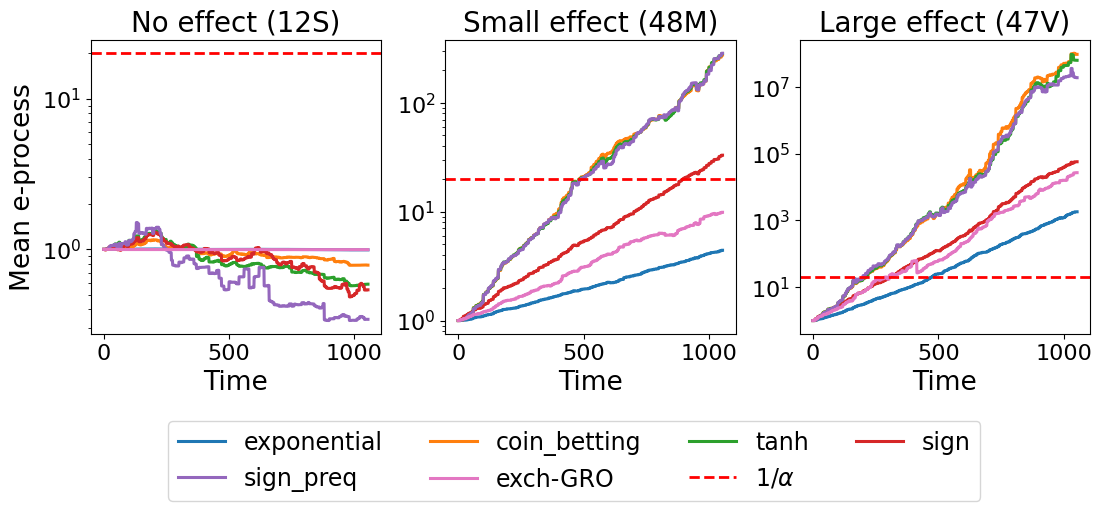

In [4]:
features = [10, 62, 61]
titles = {10: "No effect (12S)", 62: "Small effect (48M)", 61: "Large effect (47V)"}

# Same names and colors as the Gaussian-Dirichlet simulation figure
order = ["exponential", "generalized_sign", "tanh", "sign", "sign_preq", "kde_1d", "kde_2d"]
display_names = {"generalized_sign": "coin_betting", "kde_1d": "sym-GRO", "kde_2d": "exch-GRO"}
colors = {"exponential": "tab:blue", "generalized_sign": "tab:orange", "tanh": "tab:green", "sign": "tab:red",
          "sign_preq": "tab:purple", "kde_1d": "tab:brown", "kde_2d": "tab:pink"}
linewidth = 2.2
plotted = [name for name in order if name in strategies] + [name for name in strategies if name not in order]

# The figure is scaled down to the page width in LaTeX, so the fonts are large on purpose
fig, axes = plt.subplots(1, len(features), figsize=(4.3 * len(features), 4.2), sharey=False)

for ax, j in zip(np.atleast_1d(axes), features):
    for name in plotted:
        ax.plot(mean_processes[name][j].mean(axis=0), label=display_names.get(name, name),
                color=colors.get(name), linewidth=linewidth)

    ax.axhline(
        y=1 / alpha,
        color="red",
        linestyle="--",
        linewidth=2,
        label=r"$1/\alpha$"
    )

    ax.set_yscale("log")
    ax.set_title(titles.get(j, f"feature {j}"), fontsize=20)
    ax.set_xlabel("Time", fontsize=19)
    ax.tick_params(labelsize=16)

np.atleast_1d(axes)[0].set_ylabel(f"Mean e-process", fontsize=19)

# matplotlib fills legend columns first; reorder so that the legend reads row by row in the order above
ncol = 4
handles, labels = np.atleast_1d(axes)[0].get_legend_handles_labels()
nrows = -(-len(handles) // ncol)
row_wise = [r * ncol + c for c in range(ncol) for r in range(nrows) if r * ncol + c < len(handles)]
fig.legend(
    [handles[i] for i in row_wise],
    [labels[i] for i in row_wise],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=ncol,
    fontsize=17
)
fig.subplots_adjust(top=0.9, bottom=0.2, wspace=0.22)

features_str = "_".join(map(str, features))
fig.savefig(f"mean_e_process_hiv_model{model}_ninit{n_init}_n{n}_B{resamplings}{'_shuffled' if shuffled else ''}"
            f"_features_{features_str}.pdf", bbox_inches="tight")
plt.show()